# BP coverage analysis: Effect of CLAMP_K

**Environment:** `clamp-analyses`

This notebook analyzes the proportion of biological processes (BP) that are represented in CLAMP models built with different CLAMP_K values (50, 100, 250, 500, 750, 1000) using 1% random sampling of ARCHS4 data.

Results are loaded from `output/archs4/clamp_k_effect_01/` generated by `nbs/01_model_building/04_archs4/07_clamp_k_effect_01.ipynb`.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from pyprojroot.here import here

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
readRDS = ro.r["readRDS"]
as_matrix = ro.r["as.matrix"]

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
auc_threshold = 0.6
fdr_threshold = 0.1

## Load BP reference data for ARCHS4

In [3]:
bp_matched_path = here("output/archs4/BP_matched.rds")
bp_matched_archs4_r = readRDS(str(bp_matched_path))

r_rownames = ro.r.rownames(bp_matched_archs4_r)
r_colnames = ro.r.colnames(bp_matched_archs4_r)

bp_matched_dense = as_matrix(bp_matched_archs4_r)

with localconverter(ro.default_converter + pandas2ri.converter):
    data_values = ro.conversion.rpy2py(bp_matched_dense)

bp_matched_archs4_df = pd.DataFrame(
    data=data_values,
    index=list(r_rownames) if r_rownames is not ro.NULL else None,
    columns=list(r_colnames) if r_colnames is not ro.NULL else None
)

display(bp_matched_archs4_df.head())
bp_archs4_unique = bp_matched_archs4_df.columns.unique()

total_bps_archs4 = len(bp_archs4_unique)
print(f"Total unique biological processes in ARCHS4 reference: {total_bps_archs4}")

R callback write-console: Loading required package: Matrix
  


,BP_'De Novo' Post-Translational Protein Folding (GO:0051084),BP_2-Oxoglutarate Metabolic Process (GO:0006103),BP_3'-UTR-mediated mRNA Destabilization (GO:0061158),BP_3'-UTR-mediated mRNA Stabilization (GO:0070935),BP_3'-Phosphoadenosine 5'-Phosphosulfate Metabolic Process (GO:0050427),BP_ADP Catabolic Process (GO:0046032),BP_ATP Biosynthetic Process (GO:0006754),BP_ATP Metabolic Process (GO:0046034),BP_ATP Transport (GO:0015867),BP_Arp2/3 Complex-Mediated Actin Nucleation (GO:0034314),...,BP_Water Transport (GO:0006833),BP_Water-Soluble Vitamin Metabolic Process (GO:0006767),BP_Wound Healing (GO:0042060),"BP_Wound Healing, Spreading of Cells (GO:0044319)","BP_Wound Healing, Spreading of Epidermal Cells (GO:0035313)",BP_Xenobiotic Catabolic Process (GO:0042178),BP_Xenobiotic Transport (GO:0042908),BP_Zinc Ion Transmembrane Transport (GO:0071577),BP_Zinc Ion Transport (GO:0006829),BP_Zymogen Activation (GO:0031638)
A1BG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1BG-AS1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M-AS1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2ML1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Total unique biological processes in ARCHS4 reference: 3284


## Define summary file paths

Results from `clamp_k_effect_01`: 3 seeds x 6 CLAMP_K values, all at 1% random sampling.

In [4]:
base_dir = here("output/archs4/clamp_k_effect_01")

clamp_k_values = [50, 100, 250, 500, 750, 1000]
seeds = [1, 2, 3, 4, 5]

clamp_k_files = {}
for seed in seeds:
    for k in clamp_k_values:
        name = f"seed_{seed}_k_{k}"
        path = base_dir / f"seed_{seed}" / f"clamp_k_{k}" / "CLAMPfull_BP" / "summary.csv"
        clamp_k_files[name] = path

# Check which files exist
for name, path in clamp_k_files.items():
    exists = path.exists()
    if not exists:
        print(f"Missing: {name} -> {path}")

n_found = sum(1 for p in clamp_k_files.values() if p.exists())
print(f"\nFound {n_found}/{len(clamp_k_files)} summary files")


Found 30/30 summary files


## Read and process CLAMP_K results

In [5]:
results_clamp_k = []

for name, filepath in clamp_k_files.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    
    # Apply AUC and FDR filters
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    # Get unique BPs that pass the filter
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    # Parse seed and CLAMP_K from name
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_clamp_k.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_clamp_k_df = pd.DataFrame(results_clamp_k)
results_clamp_k_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_50,50,1,129,3284,0.039281
6,seed_2_k_50,50,2,122,3284,0.037150
12,seed_3_k_50,50,3,154,3284,0.046894
18,seed_4_k_50,50,4,116,3284,0.035323
24,seed_5_k_50,50,5,125,3284,0.038063
1,seed_1_k_100,100,1,194,3284,0.059074
7,seed_2_k_100,100,2,174,3284,0.052984
13,seed_3_k_100,100,3,181,3284,0.055116
19,seed_4_k_100,100,4,163,3284,0.049635
25,seed_5_k_100,100,5,185,3284,0.056334


## Plot: BP Coverage by CLAMP_K value

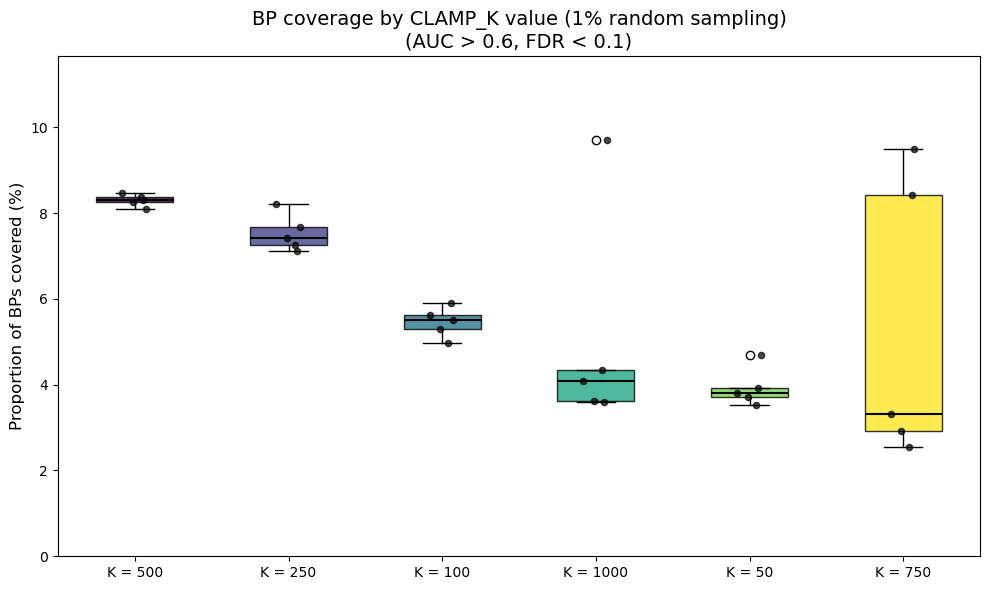

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort CLAMP_K values by median proportion (descending)
coverage_medians = (
    results_clamp_k_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

# Color palette
cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

# Create grouped data (multiply by 100 for percentage)
grouped_data = [
    results_clamp_k_df[results_clamp_k_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

# Overlay individual points
for i, k in enumerate(k_order):
    data = results_clamp_k_df[results_clamp_k_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (1% random sampling)\n"
    f"(AUC > {auc_threshold}, FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_clamp_k_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

In [7]:
auc_threshold = 0.7
fdr_threshold = 0.05

In [8]:
results_clamp_k = []

for name, filepath in clamp_k_files.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    
    # Apply AUC and FDR filters
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    # Get unique BPs that pass the filter
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    # Parse seed and CLAMP_K from name
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_clamp_k.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_clamp_k_df = pd.DataFrame(results_clamp_k)
results_clamp_k_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_50,50,1,90,3284,0.027406
6,seed_2_k_50,50,2,76,3284,0.023143
12,seed_3_k_50,50,3,116,3284,0.035323
18,seed_4_k_50,50,4,76,3284,0.023143
24,seed_5_k_50,50,5,70,3284,0.021315
1,seed_1_k_100,100,1,107,3284,0.032582
7,seed_2_k_100,100,2,54,3284,0.016443
13,seed_3_k_100,100,3,100,3284,0.030451
19,seed_4_k_100,100,4,40,3284,0.012180
25,seed_5_k_100,100,5,108,3284,0.032887


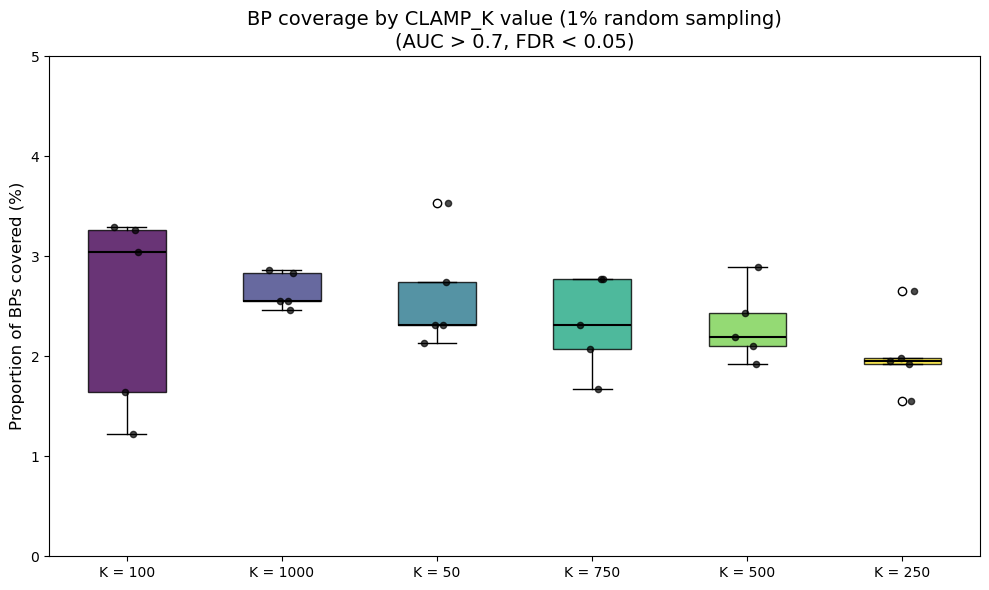

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort CLAMP_K values by median proportion (descending)
coverage_medians = (
    results_clamp_k_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

# Color palette
cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

# Create grouped data (multiply by 100 for percentage)
grouped_data = [
    results_clamp_k_df[results_clamp_k_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

# Overlay individual points
for i, k in enumerate(k_order):
    data = results_clamp_k_df[results_clamp_k_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (1% random sampling)\n"
    f"(AUC > {auc_threshold}, FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_clamp_k_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

In [10]:
fdr_threshold = 0.05

In [11]:
results_clamp_k = []

for name, filepath in clamp_k_files.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    
    # Apply FDR filter
    df_filtered = df[df["FDR"] < fdr_threshold]
    
    # Get unique BPs that pass the filter
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    # Parse seed and CLAMP_K from name
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_clamp_k.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_clamp_k_df = pd.DataFrame(results_clamp_k)
results_clamp_k_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_50,50,1,90,3284,0.027406
6,seed_2_k_50,50,2,76,3284,0.023143
12,seed_3_k_50,50,3,116,3284,0.035323
18,seed_4_k_50,50,4,76,3284,0.023143
24,seed_5_k_50,50,5,70,3284,0.021315
1,seed_1_k_100,100,1,108,3284,0.032887
7,seed_2_k_100,100,2,54,3284,0.016443
13,seed_3_k_100,100,3,101,3284,0.030755
19,seed_4_k_100,100,4,40,3284,0.012180
25,seed_5_k_100,100,5,108,3284,0.032887


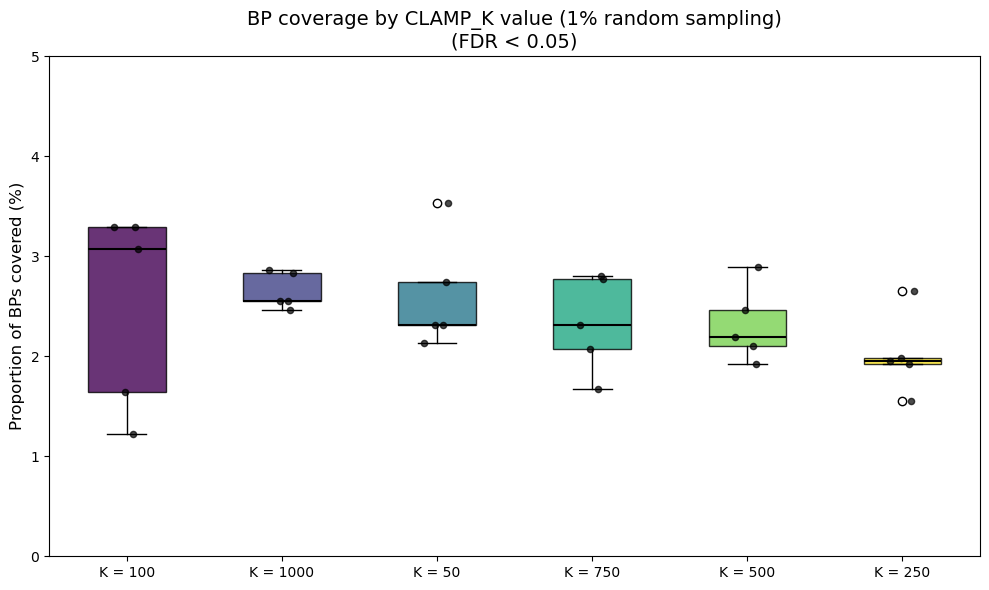

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort CLAMP_K values by median proportion (descending)
coverage_medians = (
    results_clamp_k_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

# Color palette
cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

# Create grouped data (multiply by 100 for percentage)
grouped_data = [
    results_clamp_k_df[results_clamp_k_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

# Overlay individual points
for i, k in enumerate(k_order):
    data = results_clamp_k_df[results_clamp_k_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (1% random sampling)\n"
    f"(FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_clamp_k_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

## Summary table

In [13]:
summary = (
    results_clamp_k_df
    .groupby('CLAMP_K')
    .agg(
        n_seeds=('seed', 'count'),
        mean_bps=('n_unique_bps', 'mean'),
        std_bps=('n_unique_bps', 'std'),
        mean_proportion=('proportion_covered', 'mean'),
        std_proportion=('proportion_covered', 'std'),
    )
    .round(4)
    .sort_index()
)

summary['mean_pct'] = (summary['mean_proportion'] * 100).round(2)
summary['std_pct'] = (summary['std_proportion'] * 100).round(2)

display(summary)

,n_seeds,mean_bps,std_bps,mean_proportion,std_proportion,mean_pct,std_pct
CLAMP_K,,,,,,,
50,5,85.6,18.5149,0.0261,0.0056,2.61,0.56
100,5,82.2,32.6374,0.0250,0.0099,2.50,0.99
250,5,66.0,13.0384,0.0201,0.0040,2.01,0.40
500,5,76.0,12.4499,0.0231,0.0038,2.31,0.38
750,5,76.4,15.6939,0.0233,0.0048,2.33,0.48
1000,5,87.2,5.8907,0.0266,0.0018,2.66,0.18


# BP coverage analysis: CLAMP_K with 1% study-based sampling

Results loaded from `output/archs4/clamp_k_effect_01_study/` generated by `nbs/01_model_building/04_archs4/09_clamp_k_effect_01_study.ipynb`.

In [14]:
base_dir_study = here("output/archs4/clamp_k_effect_01_study")

clamp_k_values_study = [50, 100, 250, 500, 750, 1000]
seeds_study = [1, 2, 3, 4, 5]

clamp_k_files_study = {}
for seed in seeds_study:
    for k in clamp_k_values_study:
        name = f"seed_{seed}_k_{k}"
        path = base_dir_study / f"seed_{seed}" / f"clamp_k_{k}" / "CLAMPfull_BP" / "summary.csv"
        clamp_k_files_study[name] = path

# Check which files exist
for name, path in clamp_k_files_study.items():
    exists = path.exists()
    if not exists:
        print(f"Missing: {name} -> {path}")

n_found = sum(1 for p in clamp_k_files_study.values() if p.exists())
print(f"\nFound {n_found}/{len(clamp_k_files_study)} summary files")


Found 30/30 summary files


### Plot 1: AUC > 0.6, FDR < 0.1

In [15]:
auc_threshold = 0.6
fdr_threshold = 0.1

results_study = []

for name, filepath in clamp_k_files_study.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_study.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_study_df = pd.DataFrame(results_study)
results_study_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_50,50,1,138,3284,0.042022
6,seed_2_k_50,50,2,139,3284,0.042326
12,seed_3_k_50,50,3,98,3284,0.029842
18,seed_4_k_50,50,4,126,3284,0.038368
24,seed_5_k_50,50,5,110,3284,0.033496
1,seed_1_k_100,100,1,132,3284,0.040195
7,seed_2_k_100,100,2,186,3284,0.056638
13,seed_3_k_100,100,3,131,3284,0.039890
19,seed_4_k_100,100,4,153,3284,0.046590
25,seed_5_k_100,100,5,161,3284,0.049026


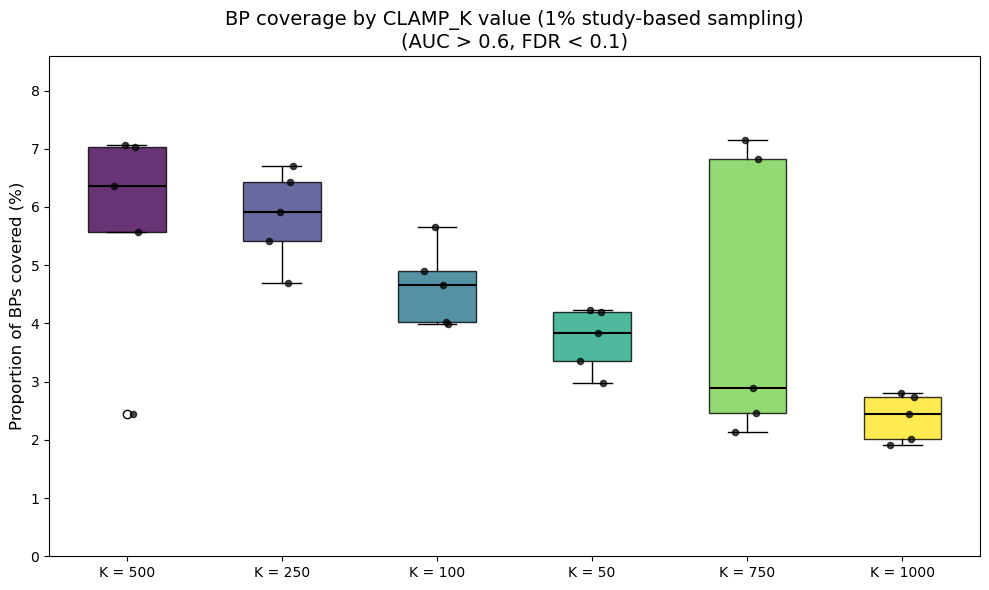

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_study_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_study_df[results_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_study_df[results_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (1% study-based sampling)\n"
    f"(AUC > {auc_threshold}, FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_study_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Plot 2: AUC > 0.7, FDR < 0.05

In [17]:
auc_threshold = 0.7
fdr_threshold = 0.05

results_study = []

for name, filepath in clamp_k_files_study.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_study.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_study_df = pd.DataFrame(results_study)
results_study_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_50,50,1,76,3284,0.023143
6,seed_2_k_50,50,2,103,3284,0.031364
12,seed_3_k_50,50,3,56,3284,0.017052
18,seed_4_k_50,50,4,75,3284,0.022838
24,seed_5_k_50,50,5,72,3284,0.021924
1,seed_1_k_100,100,1,35,3284,0.010658
7,seed_2_k_100,100,2,102,3284,0.031060
13,seed_3_k_100,100,3,40,3284,0.012180
19,seed_4_k_100,100,4,50,3284,0.015225
25,seed_5_k_100,100,5,39,3284,0.011876


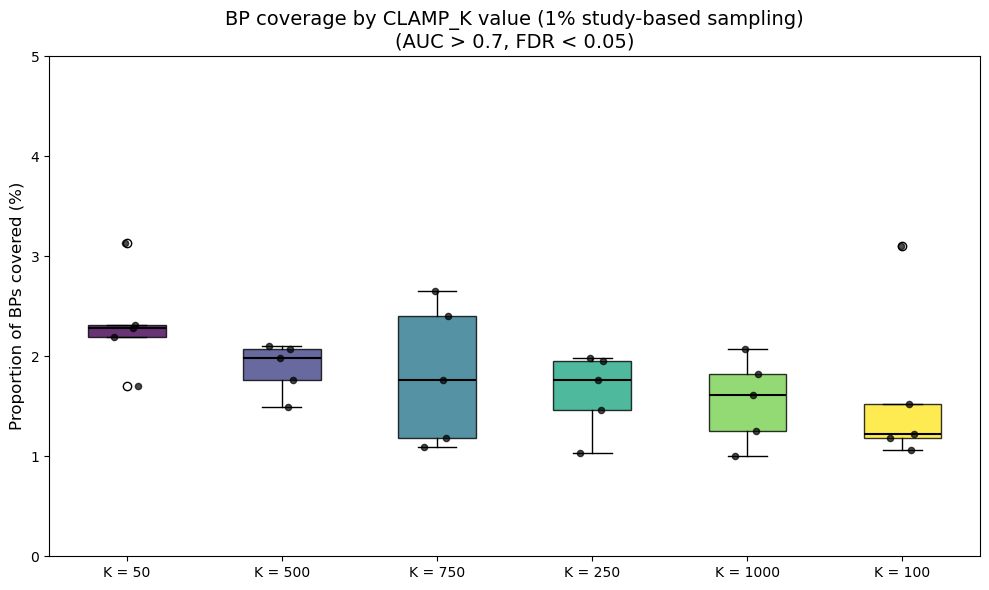

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_study_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_study_df[results_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_study_df[results_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (1% study-based sampling)\n"
    f"(AUC > {auc_threshold}, FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_study_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Plot 3: FDR < 0.05 only

In [19]:
fdr_threshold = 0.05

results_study = []

for name, filepath in clamp_k_files_study.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[df["FDR"] < fdr_threshold]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_study.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_study_df = pd.DataFrame(results_study)
results_study_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_50,50,1,76,3284,0.023143
6,seed_2_k_50,50,2,105,3284,0.031973
12,seed_3_k_50,50,3,56,3284,0.017052
18,seed_4_k_50,50,4,75,3284,0.022838
24,seed_5_k_50,50,5,72,3284,0.021924
1,seed_1_k_100,100,1,35,3284,0.010658
7,seed_2_k_100,100,2,102,3284,0.031060
13,seed_3_k_100,100,3,40,3284,0.012180
19,seed_4_k_100,100,4,50,3284,0.015225
25,seed_5_k_100,100,5,40,3284,0.012180


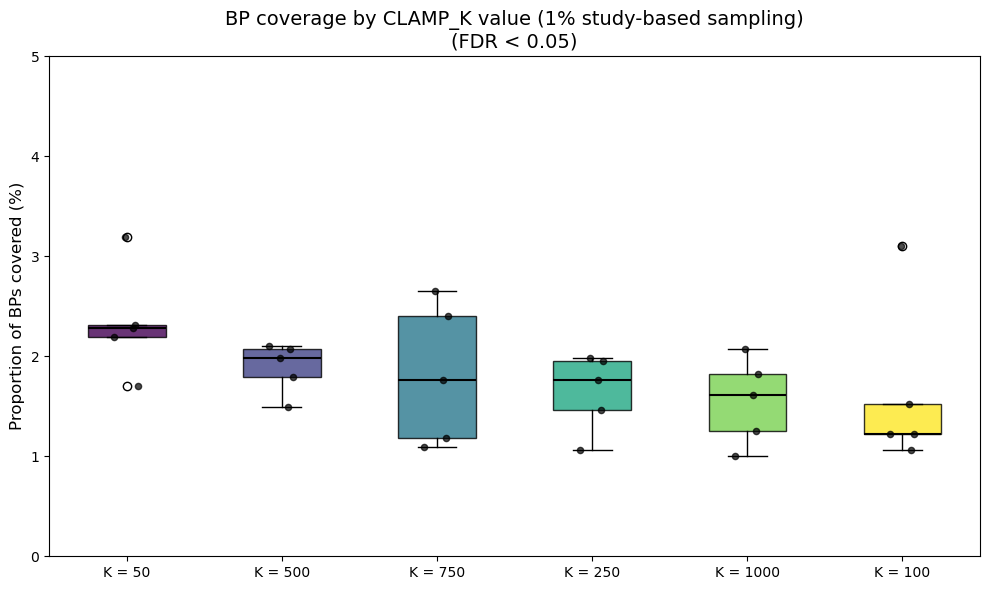

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_study_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_study_df[results_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_study_df[results_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (1% study-based sampling)\n"
    f"(FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_study_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Summary table (study-based sampling)

In [21]:
summary_study = (
    results_study_df
    .groupby('CLAMP_K')
    .agg(
        n_seeds=('seed', 'count'),
        mean_bps=('n_unique_bps', 'mean'),
        std_bps=('n_unique_bps', 'std'),
        mean_proportion=('proportion_covered', 'mean'),
        std_proportion=('proportion_covered', 'std'),
    )
    .round(4)
    .sort_index()
)

summary_study['mean_pct'] = (summary_study['mean_proportion'] * 100).round(2)
summary_study['std_pct'] = (summary_study['std_proportion'] * 100).round(2)

display(summary_study)

,n_seeds,mean_bps,std_bps,mean_proportion,std_proportion,mean_pct,std_pct
CLAMP_K,,,,,,,
50,5,76.8,17.7116,0.0234,0.0054,2.34,0.54
100,5,53.4,27.7092,0.0163,0.0084,1.63,0.84
250,5,54.0,12.5897,0.0164,0.0038,1.64,0.38
500,5,62.0,8.2462,0.0189,0.0025,1.89,0.25
750,5,59.8,22.9717,0.0182,0.0070,1.82,0.70
1000,5,51.0,14.1244,0.0155,0.0043,1.55,0.43


# BP coverage analysis: CLAMP_K with 5% random sampling

Results loaded from `output/archs4/clamp_k_effect_05/` generated by `nbs/01_model_building/04_archs4/08_clamp_k_effect_05.ipynb`.

In [22]:
base_dir_05 = here("output/archs4/clamp_k_effect_05")

clamp_k_values_05 = [250, 500, 1250, 2500, 3750, 5000]
seeds_05 = [1, 2, 3, 4, 5]

clamp_k_files_05 = {}
for seed in seeds_05:
    for k in clamp_k_values_05:
        name = f"seed_{seed}_k_{k}"
        path = base_dir_05 / f"seed_{seed}" / f"clamp_k_{k}" / "CLAMPfull_BP" / "summary.csv"
        clamp_k_files_05[name] = path

# Check which files exist
for name, path in clamp_k_files_05.items():
    exists = path.exists()
    if not exists:
        print(f"Missing: {name} -> {path}")

n_found = sum(1 for p in clamp_k_files_05.values() if p.exists())
print(f"\nFound {n_found}/{len(clamp_k_files_05)} summary files")

Missing: seed_1_k_3750 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05/seed_1/clamp_k_3750/CLAMPfull_BP/summary.csv
Missing: seed_1_k_5000 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05/seed_1/clamp_k_5000/CLAMPfull_BP/summary.csv
Missing: seed_2_k_250 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05/seed_2/clamp_k_250/CLAMPfull_BP/summary.csv
Missing: seed_2_k_500 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05/seed_2/clamp_k_500/CLAMPfull_BP/summary.csv
Missing: seed_2_k_1250 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05/seed_2/clamp_k_1250/CLAMPfull_BP/summary.csv
Missing: seed_2_k_2500 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05/seed_2/clamp_k_2500/CLAMPfull_BP/summary.csv
Missing: seed_2_k_3750 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_ef

### Plot 1: AUC > 0.6, FDR < 0.1

In [23]:
auc_threshold = 0.6
fdr_threshold = 0.1

results_05 = []

for name, filepath in clamp_k_files_05.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_05.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_05_df = pd.DataFrame(results_05)
results_05_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_250,250,1,271,3284,0.082521
1,seed_1_k_500,500,1,273,3284,0.083130
2,seed_1_k_1250,1250,1,86,3284,0.026188
3,seed_1_k_2500,2500,1,59,3284,0.017966


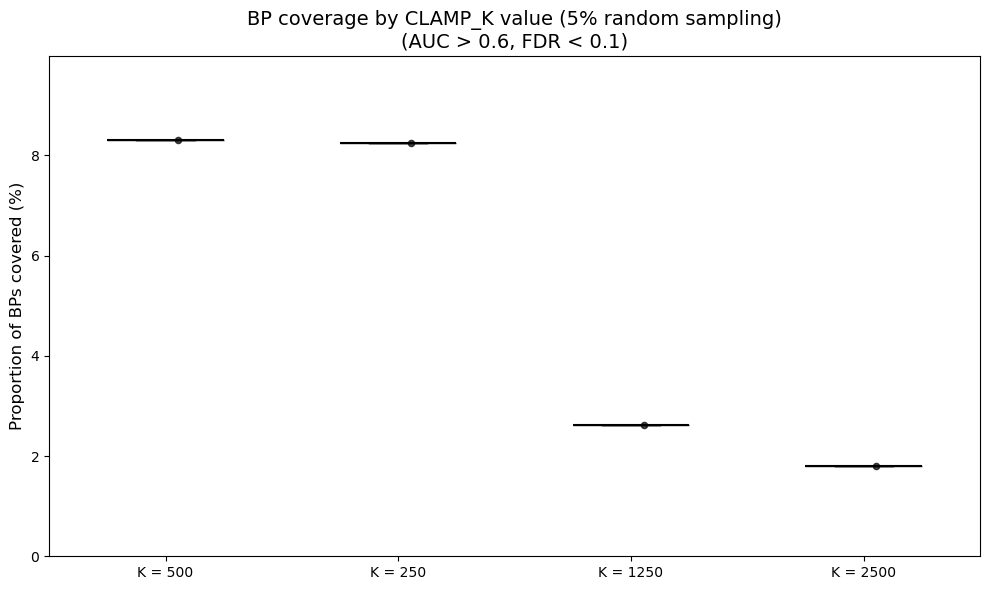

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_05_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_05_df[results_05_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_05_df[results_05_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (5% random sampling)\n"
    f"(AUC > {auc_threshold}, FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_05_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Plot 2: AUC > 0.7, FDR < 0.05

In [25]:
auc_threshold = 0.7
fdr_threshold = 0.05

results_05 = []

for name, filepath in clamp_k_files_05.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_05.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_05_df = pd.DataFrame(results_05)
results_05_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_250,250,1,76,3284,0.023143
1,seed_1_k_500,500,1,47,3284,0.014312
2,seed_1_k_1250,1250,1,46,3284,0.014007
3,seed_1_k_2500,2500,1,39,3284,0.011876


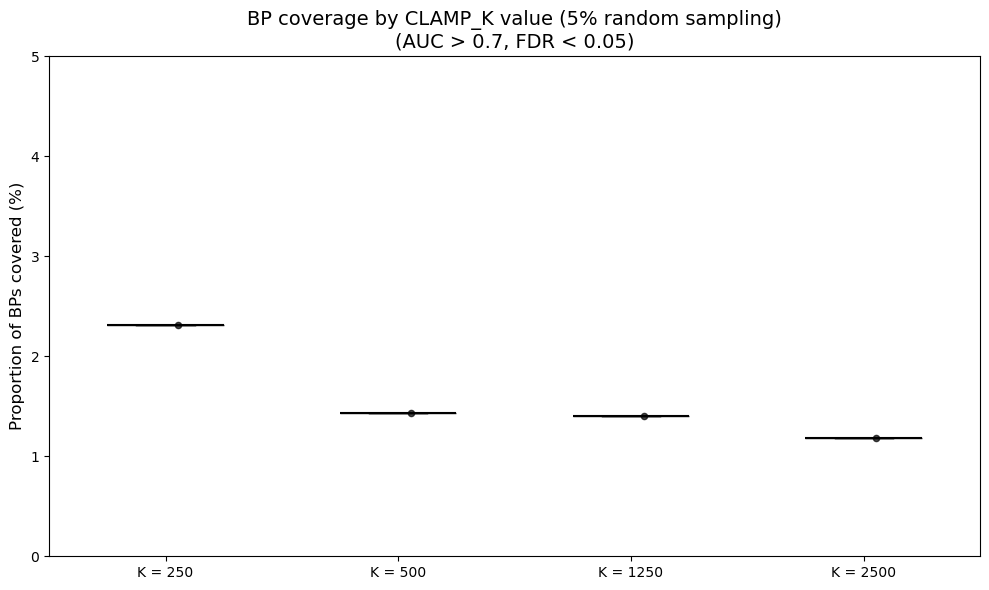

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_05_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_05_df[results_05_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_05_df[results_05_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (5% random sampling)\n"
    f"(AUC > {auc_threshold}, FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_05_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Plot 3: FDR < 0.05 only

In [27]:
fdr_threshold = 0.05

results_05 = []

for name, filepath in clamp_k_files_05.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[df["FDR"] < fdr_threshold]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_05.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_05_df = pd.DataFrame(results_05)
results_05_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_250,250,1,76,3284,0.023143
1,seed_1_k_500,500,1,47,3284,0.014312
2,seed_1_k_1250,1250,1,46,3284,0.014007
3,seed_1_k_2500,2500,1,39,3284,0.011876


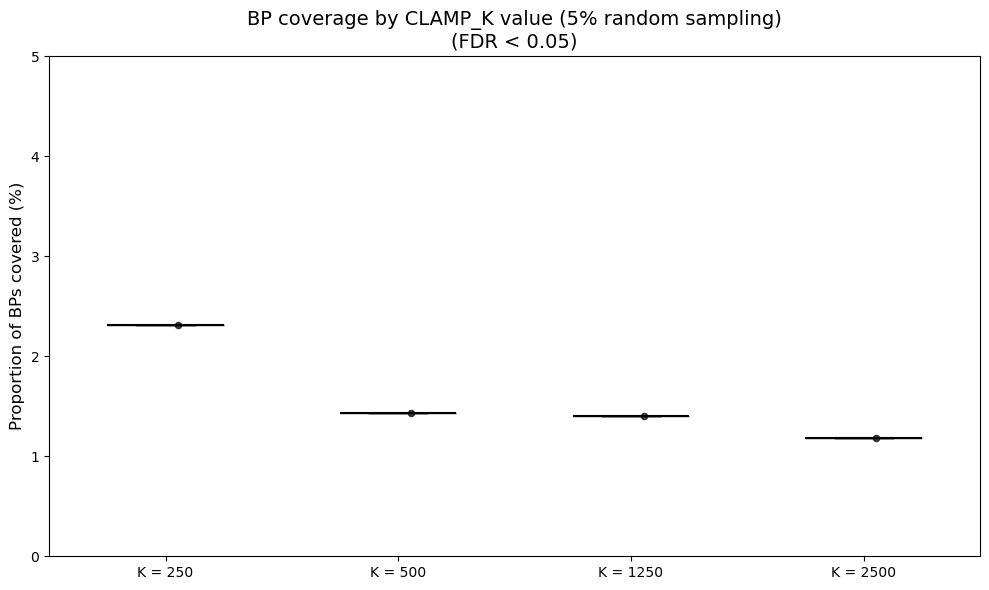

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_05_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_05_df[results_05_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_05_df[results_05_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (5% random sampling)\n"
    f"(FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_05_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Summary table (5% random sampling)

In [29]:
summary_05 = (
    results_05_df
    .groupby('CLAMP_K')
    .agg(
        n_seeds=('seed', 'count'),
        mean_bps=('n_unique_bps', 'mean'),
        std_bps=('n_unique_bps', 'std'),
        mean_proportion=('proportion_covered', 'mean'),
        std_proportion=('proportion_covered', 'std'),
    )
    .round(4)
    .sort_index()
)

summary_05['mean_pct'] = (summary_05['mean_proportion'] * 100).round(2)
summary_05['std_pct'] = (summary_05['std_proportion'] * 100).round(2)

display(summary_05)

,n_seeds,mean_bps,std_bps,mean_proportion,std_proportion,mean_pct,std_pct
CLAMP_K,,,,,,,
250,1,76.0,NaN,0.0231,NaN,2.31,NaN
500,1,47.0,NaN,0.0143,NaN,1.43,NaN
1250,1,46.0,NaN,0.0140,NaN,1.40,NaN
2500,1,39.0,NaN,0.0119,NaN,1.19,NaN


# BP coverage analysis: CLAMP_K with 5% study-based sampling

Results loaded from `output/archs4/clamp_k_effect_05_study/` generated by `nbs/01_model_building/04_archs4/10_clamp_k_effect_05_study.ipynb`.

In [30]:
base_dir_05_study = here("output/archs4/clamp_k_effect_05_study")

clamp_k_values_05_study = [250, 500, 1250, 2500, 3750, 5000]
seeds_05_study = [1, 2, 3, 4, 5]

clamp_k_files_05_study = {}
for seed in seeds_05_study:
    for k in clamp_k_values_05_study:
        name = f"seed_{seed}_k_{k}"
        path = base_dir_05_study / f"seed_{seed}" / f"clamp_k_{k}" / "CLAMPfull_BP" / "summary.csv"
        clamp_k_files_05_study[name] = path

# Check which files exist
for name, path in clamp_k_files_05_study.items():
    exists = path.exists()
    if not exists:
        print(f"Missing: {name} -> {path}")

n_found = sum(1 for p in clamp_k_files_05_study.values() if p.exists())
print(f"\nFound {n_found}/{len(clamp_k_files_05_study)} summary files")

Missing: seed_1_k_3750 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05_study/seed_1/clamp_k_3750/CLAMPfull_BP/summary.csv
Missing: seed_1_k_5000 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05_study/seed_1/clamp_k_5000/CLAMPfull_BP/summary.csv
Missing: seed_2_k_250 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05_study/seed_2/clamp_k_250/CLAMPfull_BP/summary.csv
Missing: seed_2_k_500 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05_study/seed_2/clamp_k_500/CLAMPfull_BP/summary.csv
Missing: seed_2_k_1250 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05_study/seed_2/clamp_k_1250/CLAMPfull_BP/summary.csv
Missing: seed_2_k_2500 -> /home/msubirana/Documents/pivlab/clamp-analyses/output/archs4/clamp_k_effect_05_study/seed_2/clamp_k_2500/CLAMPfull_BP/summary.csv
Missing: seed_2_k_3750 -> /home/msubirana/Documents/pivlab/cla

### Plot 1: AUC > 0.6, FDR < 0.1

In [31]:
auc_threshold = 0.6
fdr_threshold = 0.1

results_05_study = []

for name, filepath in clamp_k_files_05_study.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_05_study.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_05_study_df = pd.DataFrame(results_05_study)
results_05_study_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_250,250,1,246,3284,0.074909
1,seed_1_k_500,500,1,217,3284,0.066078
2,seed_1_k_1250,1250,1,80,3284,0.024361
3,seed_1_k_2500,2500,1,32,3284,0.009744


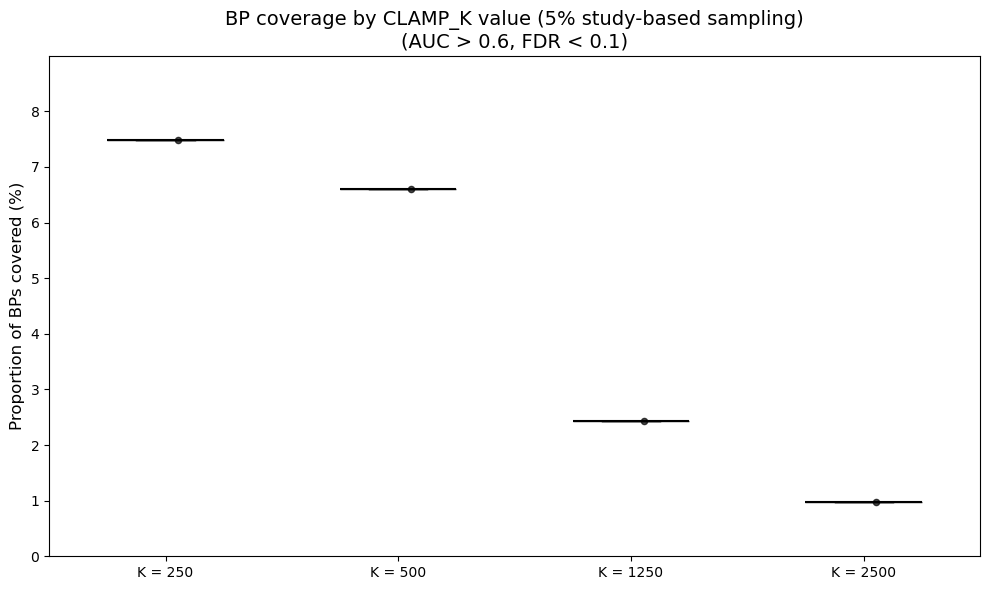

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_05_study_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_05_study_df[results_05_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_05_study_df[results_05_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (5% study-based sampling)\n"
    f"(AUC > {auc_threshold}, FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_05_study_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Plot 2: AUC > 0.7, FDR < 0.05

In [33]:
auc_threshold = 0.7
fdr_threshold = 0.05

results_05_study = []

for name, filepath in clamp_k_files_05_study.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[(df["AUC"] > auc_threshold) & (df["FDR"] < fdr_threshold)]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_05_study.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_05_study_df = pd.DataFrame(results_05_study)
results_05_study_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_250,250,1,48,3284,0.014616
1,seed_1_k_500,500,1,59,3284,0.017966
2,seed_1_k_1250,1250,1,45,3284,0.013703
3,seed_1_k_2500,2500,1,24,3284,0.007308


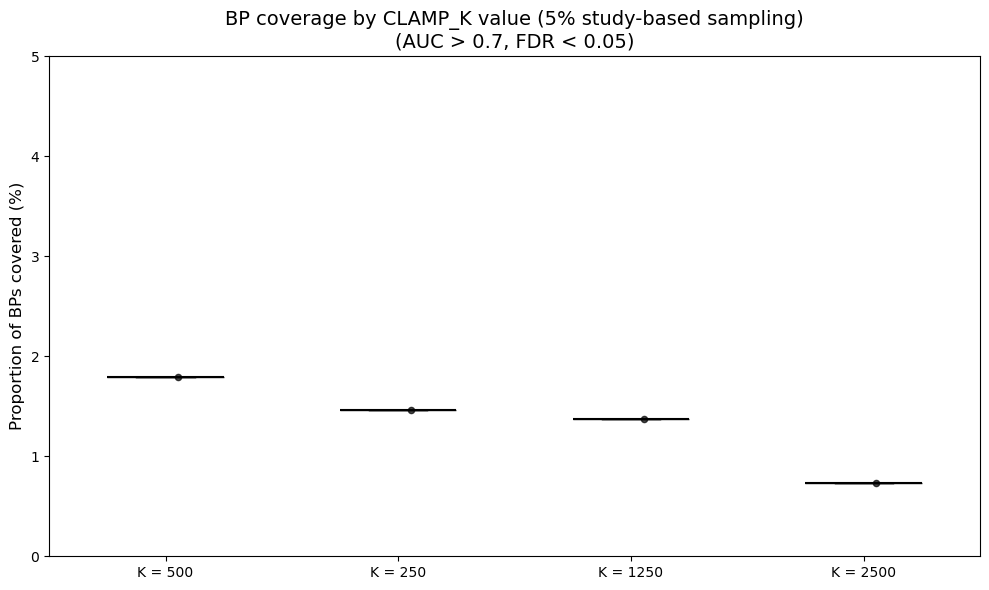

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_05_study_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_05_study_df[results_05_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_05_study_df[results_05_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (5% study-based sampling)\n"
    f"(AUC > {auc_threshold}, FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_05_study_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Plot 3: FDR < 0.05 only

In [35]:
fdr_threshold = 0.05

results_05_study = []

for name, filepath in clamp_k_files_05_study.items():
    if not filepath.exists():
        continue
    
    df = pd.read_csv(filepath, index_col=0)
    df_filtered = df[df["FDR"] < fdr_threshold]
    
    unique_bps = df_filtered["pathway"].unique()
    n_bps_covered = len(unique_bps)
    proportion = n_bps_covered / total_bps_archs4
    
    parts = name.split("_")
    seed = int(parts[1])
    k = int(parts[3])
    
    results_05_study.append({
        "name": name,
        "CLAMP_K": k,
        "seed": seed,
        "n_unique_bps": n_bps_covered,
        "total_bps": total_bps_archs4,
        "proportion_covered": proportion
    })

results_05_study_df = pd.DataFrame(results_05_study)
results_05_study_df.sort_values(["CLAMP_K", "seed"])

,name,CLAMP_K,seed,n_unique_bps,total_bps,proportion_covered
0,seed_1_k_250,250,1,48,3284,0.014616
1,seed_1_k_500,500,1,59,3284,0.017966
2,seed_1_k_1250,1250,1,45,3284,0.013703
3,seed_1_k_2500,2500,1,24,3284,0.007308


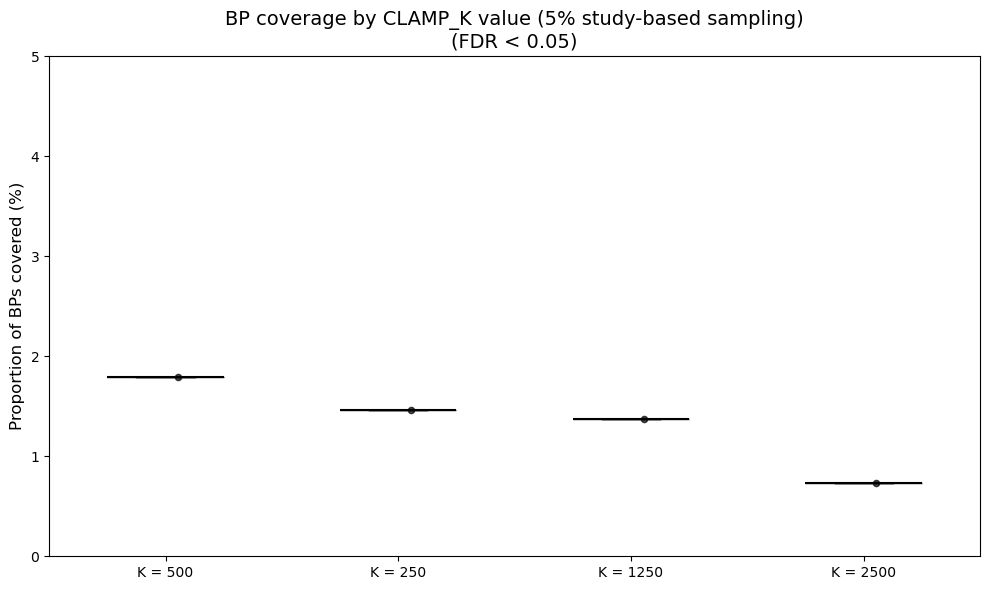

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

coverage_medians = (
    results_05_study_df
    .groupby('CLAMP_K')['proportion_covered']
    .median()
    .sort_values(ascending=False)
)
k_order = coverage_medians.index.tolist()

labels = [f"K = {k}" for k in k_order]

cmap = plt.cm.viridis
colors = [cmap(i / (len(k_order) - 1)) for i in range(len(k_order))]

grouped_data = [
    results_05_study_df[results_05_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    for k in k_order
]

bp = ax.boxplot(
    grouped_data,
    positions=range(len(k_order)),
    widths=0.5,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_alpha(0.8)

for i, k in enumerate(k_order):
    data = results_05_study_df[results_05_study_df['CLAMP_K'] == k]['proportion_covered'].values * 100
    jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
    ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=20, zorder=5, alpha=0.7)

ax.set_ylabel("Proportion of BPs covered (%)", fontsize=12)
ax.set_title(
    f"BP coverage by CLAMP_K value (5% study-based sampling)\n"
    f"(FDR < {fdr_threshold})",
    fontsize=14
)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)

max_val = results_05_study_df['proportion_covered'].max() * 100
ax.set_ylim(0, max(max_val * 1.2, 5))

plt.tight_layout()
plt.show()

### Summary table (5% study-based sampling)

In [37]:
summary_05_study = (
    results_05_study_df
    .groupby('CLAMP_K')
    .agg(
        n_seeds=('seed', 'count'),
        mean_bps=('n_unique_bps', 'mean'),
        std_bps=('n_unique_bps', 'std'),
        mean_proportion=('proportion_covered', 'mean'),
        std_proportion=('proportion_covered', 'std'),
    )
    .round(4)
    .sort_index()
)

summary_05_study['mean_pct'] = (summary_05_study['mean_proportion'] * 100).round(2)
summary_05_study['std_pct'] = (summary_05_study['std_proportion'] * 100).round(2)

display(summary_05_study)

,n_seeds,mean_bps,std_bps,mean_proportion,std_proportion,mean_pct,std_pct
CLAMP_K,,,,,,,
250,1,48.0,NaN,0.0146,NaN,1.46,NaN
500,1,59.0,NaN,0.0180,NaN,1.80,NaN
1250,1,45.0,NaN,0.0137,NaN,1.37,NaN
2500,1,24.0,NaN,0.0073,NaN,0.73,NaN


# Combined overview: All datasets and thresholds

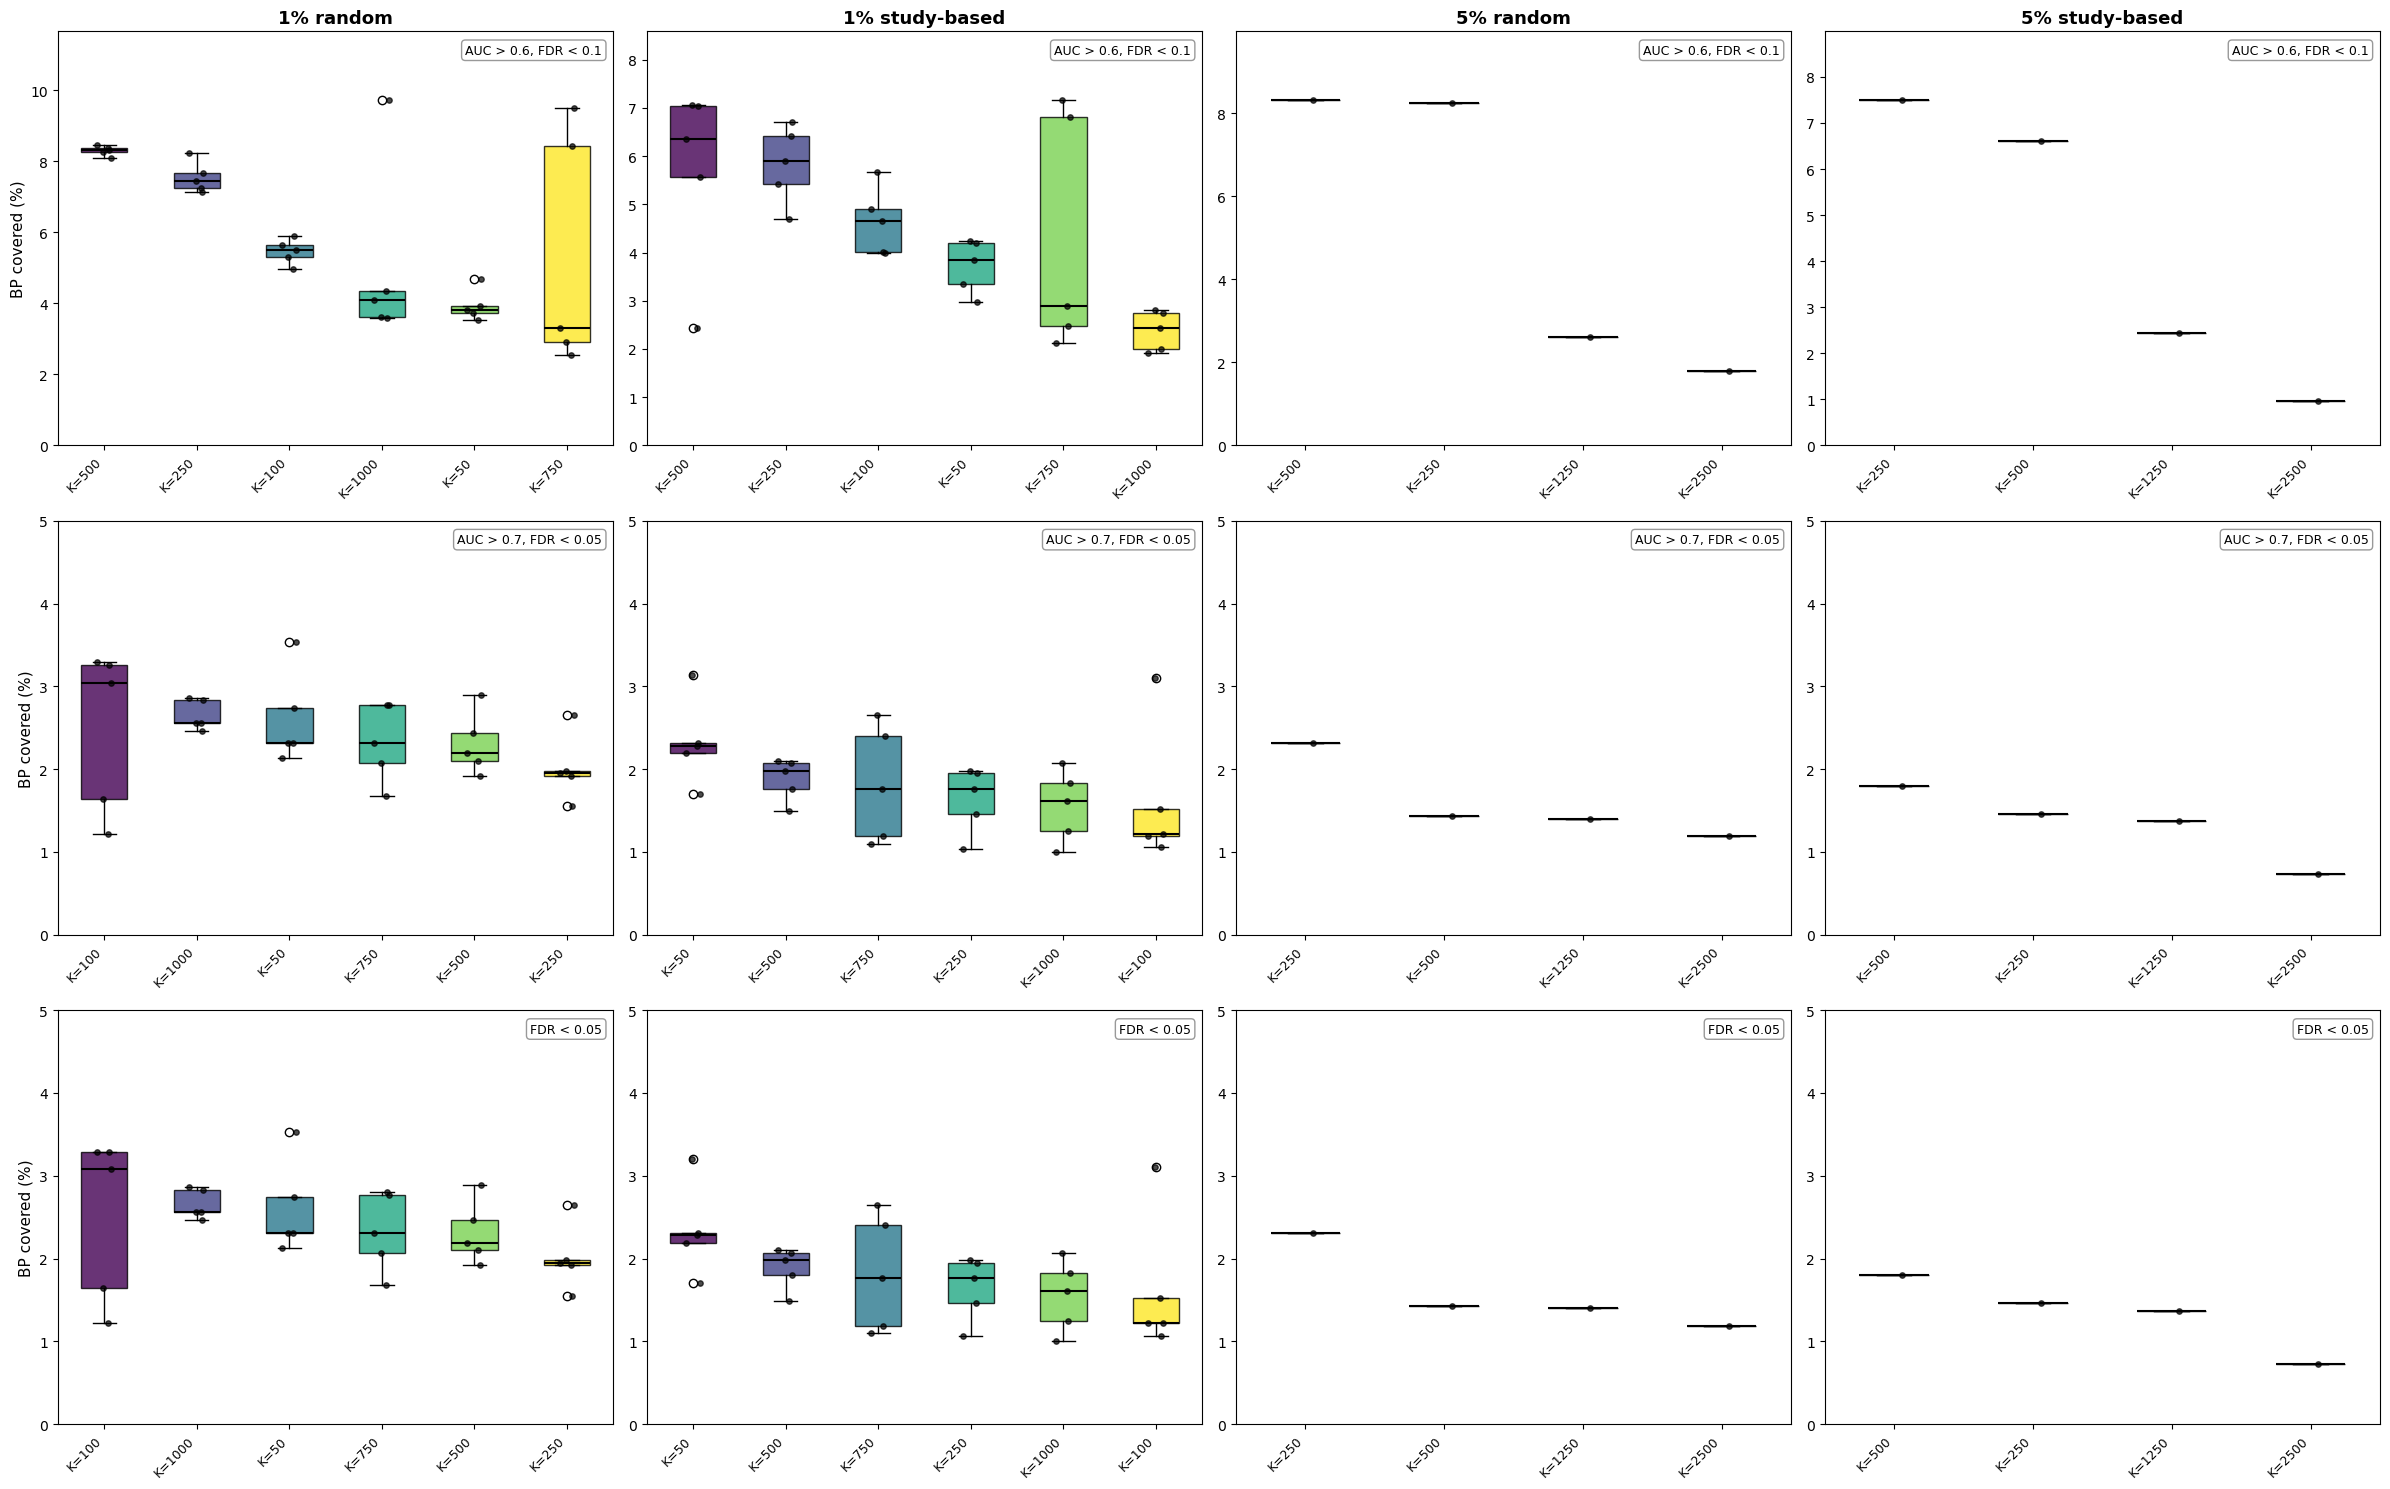

In [38]:
def compute_bp_coverage(files_dict, total_bps, auc_thresh=None, fdr_thresh=None):
    """Compute BP coverage results from summary files."""
    results = []
    for name, filepath in files_dict.items():
        if not filepath.exists():
            continue
        df = pd.read_csv(filepath, index_col=0)
        if auc_thresh is not None and fdr_thresh is not None:
            df_filtered = df[(df["AUC"] > auc_thresh) & (df["FDR"] < fdr_thresh)]
        elif fdr_thresh is not None:
            df_filtered = df[df["FDR"] < fdr_thresh]
        else:
            df_filtered = df

        unique_bps = df_filtered["pathway"].unique()
        n_bps_covered = len(unique_bps)

        parts = name.split("_")
        seed = int(parts[1])
        k = int(parts[3])

        results.append({
            "CLAMP_K": k,
            "seed": seed,
            "proportion_covered": n_bps_covered / total_bps
        })
    return pd.DataFrame(results)


# Define datasets
datasets = [
    ("1% random", clamp_k_files),
    ("1% study-based", clamp_k_files_study),
    ("5% random", clamp_k_files_05),
    ("5% study-based", clamp_k_files_05_study),
]

# Define threshold combos
thresholds = [
    ("AUC > 0.6, FDR < 0.1", 0.6, 0.1),
    ("AUC > 0.7, FDR < 0.05", 0.7, 0.05),
    ("FDR < 0.05", None, 0.05),
]

n_rows = len(thresholds)
n_cols = len(datasets)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

for row, (thresh_label, auc_t, fdr_t) in enumerate(thresholds):
    for col, (ds_label, ds_files) in enumerate(datasets):
        ax = axes[row, col]

        res_df = compute_bp_coverage(ds_files, total_bps_archs4, auc_thresh=auc_t, fdr_thresh=fdr_t)

        if res_df.empty:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
            continue

        coverage_medians = (
            res_df.groupby('CLAMP_K')['proportion_covered']
            .median()
            .sort_values(ascending=False)
        )
        k_order = coverage_medians.index.tolist()
        labels = [f"K={k}" for k in k_order]

        cmap = plt.cm.viridis
        colors = [cmap(i / max(len(k_order) - 1, 1)) for i in range(len(k_order))]

        grouped_data = [
            res_df[res_df['CLAMP_K'] == k]['proportion_covered'].values * 100
            for k in k_order
        ]

        bp = ax.boxplot(
            grouped_data,
            positions=range(len(k_order)),
            widths=0.5,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black')
        )

        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_alpha(0.8)

        for i, k in enumerate(k_order):
            data = res_df[res_df['CLAMP_K'] == k]['proportion_covered'].values * 100
            jitter = np.random.default_rng(42).uniform(-0.1, 0.1, size=len(data))
            ax.scatter(np.full_like(data, i) + jitter, data, color='black', s=15, zorder=5, alpha=0.7)

        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')

        max_val = res_df['proportion_covered'].max() * 100
        ax.set_ylim(0, max(max_val * 1.2, 5))

        # Threshold text inside each subplot
        ax.text(
            0.98, 0.97, thresh_label,
            transform=ax.transAxes, fontsize=9,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8)
        )

        if col == 0:
            ax.set_ylabel("BP covered (%)", fontsize=11)
        if row == 0:
            ax.set_title(f"{ds_label}", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()